# Overview  
Synthetic Control Method (SCM) implementation for analyzing migration flows. Estimates the treatment effect on migration from a treated origin to a treated destination.
# Key Components
## Data & Setup:
- Loads migration flow data (monthly, country pairs)
- Currently configured for TR→DE (Turkey to Germany)
- Treatment date: 2021-12-01
## Donor Selection:
- Same-origin donors: `TREATED_FROM → other destinations`
- Same-destination donors: `other origins → TREATED_TO`
- Selects top K most similar flows by total migration volume
## Model Specifications:
- Combined: Uses both origin and destination donors with group-share constraints (≥40% each)
- Origin-only: Only same-origin donors
- Destination-only: Only same-destination donors
- Leave-one-out: Sensitivity check removing top-weighted donor
## Optimisation:
- Uses CVXPy to solve constrained QP
- Finds non-negative weights summing to 1
- Supports weight caps and group-share constraints
- Robust solver with fallbacks (OSQP → ECOS → SCS → NNLS)
## Diagnostics & Validation:
- Pre-fit metrics (R², correlation, MAPE, pre-trend tests)
- Unit placebos (treating each donor as treated)
- Month placebos (using pre-treatment months as fake treatment dates)
- MSPE ratios for inference
## Additional Analyses:
- Share-of-destination test (treated flow as % of total destination inflow)
- Double-counterfactual decomposition (gaps vs origin-only vs destination-only synthetics)
## Output:
- Exports CSV tables (series, gaps, weights, placebos)
- Generates visualizations (fits, gaps, histograms)
- Saves to `SCM_results/{TREATED_FROM}/`

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cvxpy as cp
from statsmodels.api import OLS, add_constant
import statsmodels.api as sm
from scipy.stats import linregress
from tqdm import tqdm

In [ ]:
# ----------------------------- Utilities -----------------------------
@dataclass
class FitResult:
    synth: np.ndarray
    weights: np.ndarray
    status: str


def require_columns(df: pd.DataFrame, cols: list[str]):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in CSV: {missing}")


def load_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    require_columns(df, ["migration_month", "country_from", "country_to", "num_migrants"])

    df = df.copy()
    df["migration_month"] = pd.to_datetime(df["migration_month"])
    df["year"] = df["migration_month"].dt.year
    df["month"] = df["migration_month"].dt.month
    df["country_to"] = df["country_to"].astype(str)
    df["country_from"] = df["country_from"].astype(str)
    return df


def pick_similar_donors(df: pd.DataFrame,
                        treated_from: str,
                        treated_to: str,
                        exclude_origins: list[str],
                        top_k: int) -> tuple[pd.DataFrame, pd.DataFrame, float]:
    """Return monthly rows for two donor sets and the treated total (levels).
    - same-origin (treated_from -> other destinations)
    - same-destination (other origins -> treated_to)
    """
    totals = df.groupby(["country_from", "country_to"], as_index=False)["num_migrants"].sum()

    # treated total (levels)
    treated_total = (
        totals.loc[(totals["country_from"] == treated_from) &
                   (totals["country_to"] == treated_to), "num_migrants"]
        .iloc[0]
    )

    # same-origin donors: treated_from -> other destinations (exclude treated_to)
    same_origin_total = totals[(totals["country_from"] == treated_from) &
                               (totals["country_to"] != treated_to)]
    same_origin_top = same_origin_total.iloc[(same_origin_total["num_migrants"] - treated_total)
                                             .abs().argsort()[:top_k]]
    same_origin_dests = same_origin_top["country_to"].unique()
    same_origin_monthly = df[(df["country_from"] == treated_from) &
                             (df["country_to"].isin(same_origin_dests))]

    # same-destination donors: other origins -> treated_to
    same_dest_total = totals[(totals["country_to"] == treated_to)]
    same_dest_total = same_dest_total[~same_dest_total["country_from"].isin(exclude_origins + [treated_from])]
    same_dest_total = same_dest_total[(same_dest_total["country_from"] != treated_from) |
                                      (same_dest_total["country_to"] != treated_to)]
    same_dest_top = same_dest_total.iloc[(same_dest_total["num_migrants"] - treated_total)
                                         .abs().argsort()[:top_k]]
    same_dest_origins = same_dest_top["country_from"].unique()
    same_dest_monthly = df[(df["country_to"] == treated_to) &
                           (df["country_from"].isin(same_dest_origins))]

    return same_origin_monthly.copy(), same_dest_monthly.copy(), float(treated_total)


def make_panel(df_control: pd.DataFrame) -> pd.DataFrame:
    dfc = df_control.copy()
    dfc["unit"] = dfc["country_from"] + "->" + dfc["country_to"]
    dfc["month"] = dfc["migration_month"].dt.to_period("M").dt.to_timestamp()
    panel = (dfc.pivot_table(index="month", columns="unit", values="num_migrants", aggfunc="sum")
                 .sort_index())

    # Fill missing months
    all_months = pd.date_range(panel.index.min(), panel.index.max(), freq="MS")
    panel = panel.reindex(all_months)
    if FILL_METHOD == "zero":
        panel = panel.fillna(0)
    else:  # interpolate (both ways)
        panel = panel.interpolate(limit_direction="both")
    return panel


def to_modelling_scale(values: np.ndarray, use_log: bool) -> np.ndarray:
    return np.log1p(values) if use_log else values.astype(float)


def to_level_scale(values: np.ndarray, use_log: bool) -> np.ndarray:
    return np.expm1(values) if use_log else values.astype(float)


def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)


def label_slug(*parts: str) -> str:
    # build filesystem-friendly slug
    txt = "_".join([s for s in parts if s])
    return txt.replace(" ", "-").replace(".", "p").replace(":", "-")


def savefig(path: Path):
    if SAVE_FIGS:
        plt.savefig(path, dpi=200, bbox_inches='tight')


def write_csv(df: pd.DataFrame, *name_parts: str):
    """Save df to OUTPUT_DIR using label_slug on name_parts."""
    if SAVE_TABLES:
        ensure_dir(OUTPUT_DIR)
        fname = label_slug(*name_parts) + ".csv"
        df.to_csv(OUTPUT_DIR / fname, index=False)


def fit_synth(y_target: np.ndarray,
              Y_pool: np.ndarray,
              pre_mask: np.ndarray,
              group_indices: dict[str, list[int]] | None = None,
              min_group_share: float | None = None,
              weight_cap: float | None = None,
              solver: str = "OSQP") -> FitResult:
    """Fit nonnegative weights summing to 1; robust to flat/degenerate pre periods."""
    T, J = Y_pool.shape
    if J < 1:
        raise ValueError("No donors in Y_pool")

    Ypre = Y_pool[pre_mask, :]
    ypre = y_target[pre_mask]

    # If pre matrix is empty or all ~0, return uniform
    if Ypre.size == 0 or np.allclose(Ypre, 0.0):
        w_opt = np.ones(J) / J
        return FitResult(synth=Y_pool.dot(w_opt), weights=w_opt, status="fallback_uniform_Ypre_zero")

    # Build constrained QP: min ||Ypre w - ypre||^2 + ridge ||w||^2  s.t. w>=0, sum w=1 (+ caps/shares)
    w = cp.Variable(J, nonneg=True)
    constraints = [cp.sum(w) == 1]
    if weight_cap is not None and weight_cap < 1.0:
        constraints.append(w <= weight_cap)
    if min_group_share is not None and group_indices:
        for idxs in group_indices.values():
            if idxs and 0 < min_group_share < 1:
                constraints.append(cp.sum(cp.hstack([w[i] for i in idxs])) >= min_group_share)

    ridge = 1e-8
    obj = cp.sum_squares(Ypre @ w - ypre) + ridge * cp.sum_squares(w)
    prob = cp.Problem(cp.Minimize(obj), constraints)

    # Try multiple solvers with tighter tolerances where possible
    tried = []
    best_cvxp = None
    for s, kwargs in [
        (solver,            {}),
        ("ECOS",            {"abstol": 1e-8, "reltol": 1e-8, "feastol": 1e-8, "max_iters": 20000}),
        ("OSQP",            {"eps_abs": 1e-8, "eps_rel": 1e-8, "max_iter": 200000}),
        ("SCS",             {"eps": 1e-5, "max_iters": 100000, "acceleration_lookback": 20})
    ]:
        if s in tried:
            continue
        tried.append(s)
        try:
            prob.solve(solver=s, warm_start=True, verbose=False, **kwargs)
            status = prob.status or "unknown"
            # Accept only high-quality statuses
            if status in ("optimal", "optimal_inaccurate"):
                w_val = None if w.value is None else np.array(w.value).flatten()
                if w_val is not None and np.all(np.isfinite(w_val)):
                    best_cvxp = (status, w_val, prob.value)
                    if status == "optimal":
                        break  # good enough; stop trying
        except Exception:
            continue

    # Helper: NNLS fallback (no caps/group shares)
    def nnls_fallback():
        try:
            from scipy.optimize import nnls
            ww, _ = nnls(Ypre, ypre)
            if ww.sum() > 0:
                ww = ww / ww.sum()
            else:
                ww = np.ones(J) / J
            # Objective value comparable to CVXPy's objective (without ridge term)
            resid = Ypre @ ww - ypre
            return ww, float(resid @ resid)
        except Exception:
            # Column-norm heuristic if scipy isn't available
            col_norm = np.linalg.norm(Ypre, axis=0)
            if col_norm.sum() > 0:
                ww = col_norm / col_norm.sum()
            else:
                ww = np.ones(J) / J
            resid = Ypre @ ww - ypre
            return ww, float(resid @ resid)

    # Decide which solution to use
    if best_cvxp is not None:
        status, w_cvx, obj_cvx = best_cvxp
        # enforce feasibility (>=0, sum=1)
        w_cvx = np.maximum(w_cvx, 0.0)
        if w_cvx.sum() > 0:
            w_cvx = w_cvx / w_cvx.sum()
        else:
            status = status + "_sum0"

        # If constraints include caps/group shares, NNLS may violate them; prefer CVXPy unless it's clearly poor
        constraints_present = (weight_cap is not None and weight_cap < 1.0) or (min_group_share not in (None, 0.0))
        if not constraints_present:
            w_nnls, obj_nnls = nnls_fallback()
            # compare residuals on the same objective (without ridge); recompute cvx residual:
            resid_cvx = Ypre @ w_cvx - ypre
            obj_cvx_plain = float(resid_cvx @ resid_cvx)
            # If NNLS is clearly better or cvx status was "optimal_inaccurate", switch
            if obj_nnls + 1e-10 < 0.95 * obj_cvx_plain or status.startswith("optimal_inaccurate"):
                w_use, use_status = w_nnls, "fallback_nnls"
            else:
                w_use, use_status = w_cvx, status
        else:
            w_use, use_status = w_cvx, status
    else:
        # No acceptable CVXPy solution — use NNLS/heuristic
        w_use, nnls_obj = nnls_fallback()
        use_status = "fallback_nnls_no_cvx"

    synth = Y_pool.dot(w_use)
    return FitResult(synth=synth, weights=w_use, status=use_status)


def diagnostics(y_target: np.ndarray,
                synth: np.ndarray,
                pre_mask: np.ndarray,
                post_mask: np.ndarray,
                use_log: bool) -> dict:
    # Work on modelling scale for RMSPE/MSPE
    pre_err = y_target[pre_mask] - synth[pre_mask]
    post_err = y_target[post_mask] - synth[post_mask]
    pre_mspe = float(np.mean(pre_err ** 2)) if pre_mask.any() else np.nan
    post_mspe = float(np.mean(post_err ** 2)) if post_mask.any() else np.nan

    # ATT in levels
    treated_levels = to_level_scale(y_target, use_log)
    synth_levels   = to_level_scale(synth, use_log)
    cum_att        = float(treated_levels[post_mask].sum() - synth_levels[post_mask].sum())
    synth_post_sum = float(synth_levels[post_mask].sum())

    EPS = 1e-9
    pct_change = float(cum_att / synth_post_sum) if synth_post_sum > EPS else np.nan

    return {
        "pre_rmspe": float(np.sqrt(pre_mspe)) if np.isfinite(pre_mspe) else np.nan,
        "post_rmspe": float(np.sqrt(post_mspe)) if np.isfinite(post_mspe) else np.nan,
        "mspe_ratio": float(post_mspe / (pre_mspe + 1e-12)) if np.isfinite(pre_mspe) else np.nan,
        "cum_att_levels": cum_att,
        "pct_change_post": pct_change,
    }


def pre_fit_validity_metrics(y_target: np.ndarray, synth: np.ndarray, pre_mask: np.ndarray, use_log: bool) -> dict:
    """Return R^2, correlation, MAPE in levels, and a pre-trend test for the pre-period."""
    y_pre = y_target[pre_mask]
    s_pre = synth[pre_mask]
    if y_pre.size == 0:
        return {k: np.nan for k in ["pre_r2","pre_corr","pre_mape","pre_gap_slope","pre_gap_trend_p"]}

    # R^2 and correlation (modelling scale)
    ss_res = float(np.sum((y_pre - s_pre)**2))
    ss_tot = float(np.sum((y_pre - np.mean(y_pre))**2))
    r2 = 1.0 - ss_res/(ss_tot + 1e-12)
    corr = float(np.corrcoef(y_pre, s_pre)[0, 1]) if y_pre.size > 1 else np.nan

    # MAPE in *levels* (robust to log usage)
    yL = to_level_scale(y_pre, use_log)
    sL = to_level_scale(s_pre, use_log)
    mape = float(np.mean(np.abs((yL - sL) / (yL + 1e-12)))) if yL.size > 0 else np.nan

    # Pre-trend test on the gap (slope ~ 0 under good pre-fit)
    gap_pre = (y_pre - s_pre)
    if gap_pre.size > 1:
        x = np.arange(gap_pre.size)
        lr = linregress(x, gap_pre)
        slope = float(lr.slope)
        pval = float(lr.pvalue)
    else:
        slope = np.nan
        pval = np.nan

    return {"pre_r2": r2, "pre_corr": corr, "pre_mape": mape, "pre_gap_slope": slope, "pre_gap_trend_p": pval}


def unit_placebo_gaps(y_target: np.ndarray, donor_df: pd.DataFrame, pre_mask: np.ndarray) -> dict:
    """For each donor treated as pseudo-treated, return its full-period gap series (modelling scale)."""
    gaps = {}
    cols = list(donor_df.columns)
    for c in cols:
        others = [x for x in cols if x != c]
        if len(others) < 3:
            continue
        y_p = donor_df[c].values
        fr_p = fit_synth(y_p, donor_df[others].values, pre_mask)
        gaps[c] = y_p - fr_p.synth
    return gaps


def plot_pre_fit_scatter(dates: pd.DatetimeIndex, y_pre: np.ndarray, s_pre: np.ndarray, use_log: bool, title: str = "Pre-period fit (levels)"):
    yL = to_level_scale(y_pre, use_log)
    sL = to_level_scale(s_pre, use_log)
    plt.figure(figsize=(6, 6))
    plt.scatter(yL, sL, alpha=0.7)
    maxv = float(np.nanmax([yL.max(), sL.max()])) if yL.size and sL.size else 1.0
    plt.plot([0, maxv], [0, maxv], linestyle='--')
    plt.xlabel('Treated (levels)')
    plt.ylabel('Synthetic (levels)')
    plt.title(title)
    plt.tight_layout(); plt.show()


def plot_placebo_gaps(dates: pd.DatetimeIndex, treated_gap: np.ndarray, placebo_gaps: dict, treatment_idx: int, title: str):
    plt.figure(figsize=(12, 5))
    for g in placebo_gaps.values():
        plt.plot(dates, g, linewidth=0.8, alpha=0.35)
    plt.plot(dates, treated_gap, linewidth=2.0, label='Treated gap',)
    plt.axvline(dates[treatment_idx], color='k', linestyle=':')
    plt.hlines(0, dates.min(), dates.max(), linewidth=0.8)
    plt.legend(); plt.title(title)
    plt.tight_layout(); plt.show()


def unit_placebos(y_target: np.ndarray, donor_df: pd.DataFrame,
                  pre_mask: np.ndarray, post_mask: np.ndarray) -> tuple[float, dict, float, int]:
    """Run donor-level (unit) placebos, return treated ratio, dict of placebo ratios, p-value, N."""
    # treated fit (no group constraints for placebos)
    fr = fit_synth(y_target, donor_df.values, pre_mask)
    treated_ratio = diagnostics(y_target, fr.synth, pre_mask, post_mask, use_log=False)["mspe_ratio"]

    ratios = {}
    cols = list(donor_df.columns)
    for c in cols:
        others = [x for x in cols if x != c]
        if len(others) < 3:
            continue
        y_p = donor_df[c].values
        fr_p = fit_synth(y_p, donor_df[others].values, pre_mask)
        ratios[c] = diagnostics(y_p, fr_p.synth, pre_mask, post_mask, use_log=False)["mspe_ratio"]

    vals = np.array(list(ratios.values()))
    if vals.size == 0:
        pval, n = np.nan, 0
    else:
        n = vals.size
        pval = (np.sum(vals >= treated_ratio) + 1) / (n + 1)
    return float(treated_ratio), ratios, float(pval), int(n)


def month_placebos(y_target: np.ndarray, donor_df: pd.DataFrame,
                   time_index: pd.DatetimeIndex, treatment_date: pd.Timestamp,
                   use_log: bool, n_months: int) -> pd.DataFrame:
    """Run month-placebos using last n pre-treatment months; keep post window length fixed."""
    results = []
    orig_post_mask = (time_index >= treatment_date)
    T_post = int(orig_post_mask.sum())
    pre_months = time_index[time_index < treatment_date]
    candidates = list(pre_months[-n_months:])

    for pm in tqdm(candidates, desc="month-placebos"):
        pre_mask = (time_index < pm)
        post_end = pd.Timestamp(pm) + pd.DateOffset(months=T_post)
        post_mask = (time_index >= pm) & (time_index < post_end)

        if pre_mask.sum() < max(MIN_PRE_MONTHS, 6) or post_mask.sum() == 0:
            results.append({"placebo_date": pm, "status": "insufficient_pre_or_post"})
            continue

        fr = fit_synth(y_target, donor_df.values, pre_mask)
        d = diagnostics(y_target, fr.synth, pre_mask, post_mask, use_log)
        results.append({
            "placebo_date": pm,
            "status": fr.status,
            "pre_rmspe": d["pre_rmspe"],
            "post_rmspe": d["post_rmspe"],
            "mspe_ratio": d["mspe_ratio"],
            "cum_att_levels": d["cum_att_levels"],
            "pct_change_post": d["pct_change_post"],
        })

    out = pd.DataFrame(results).sort_values("placebo_date").reset_index(drop=True)
    if not out.empty and "placebo_date" in out:
        out["placebo_date_str"] = out["placebo_date"].dt.strftime("%Y-%m-%d")
    return out

In [7]:
# ----------------------------- Configuration -----------------------------
CSV_PATH = Path("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Oxford/Migration/international_migration_flow.csv")

TREATED_FROM = "CL"
TREATED_TO = "US"
TREATMENT_DATE = pd.Timestamp("2021-01-01")
EXCLUDE_ORIGINS = ["RU", "UA", "AF", "HT"]  # excluded from any->US search

# TREATED_FROM = "TR"
# TREATED_TO = "DE"
# TREATMENT_DATE = pd.Timestamp("2021-12-01")
# # TREATMENT_DATE = pd.Timestamp("2022-06-01")
# # EXCLUDE_ORIGINS = ["PL", "IN"] 
# EXCLUDE_ORIGINS = []  


# Donor selection & modelling
TOP_K = 10                                        # how many similar flows to use per side
USE_LOG = True                                    # default modelling scale (can be overridden by RUN_BOTH_LOG_SPECS)
MIN_PRE_MONTHS = 12                               # minimum pre months required

# Group-share constraints (only for combined models)
MIN_GROUP_SHARE = 0.40  # each of origin & destination groups >= 0.40 (if present)

# Sensitivity toggles
RUN_BOTH_LOG_SPECS = True                 # run both log1p and raw-count specs
RUN_SENSITIVITY_CONSTRAINTS = True        # run combined models at multiple group thresholds
CONSTRAINT_LEVELS = [0.30, 0.40, 0.50]
RUN_WEIGHT_CAP_VARIANT = True             # run combined with a per-donor cap in addition
WEIGHT_CAP = 0.50                         # max weight per single donor (only for combined models when enabled)
PLACEBOS_FOR_ALL_SPECS = False            # if False, run month-placebos only for the first (baseline) spec

# Optional leave-one-out donor behavior now automatic (we remove top-weight donor)

# Interpolation for missing months in panel: "interpolate" | "zero"
FILL_METHOD = "interpolate"

# Month-placebo settings
RUN_MONTH_PLACEBOS = True
N_PLACEBO_MONTHS = 12  # try the last N pre-treatment months as placebo dates

# Export settings
OUTPUT_DIR = Path(f"/Users/wenlanzhang/PycharmProjects/Mapineq/src/case_study/Migration/DID/SCM_results/{TREATED_FROM}")
SAVE_FIGS = False
SAVE_TABLES = True

In [8]:
# For Main Result
RUN_BOTH_LOG_SPECS = False
USE_LOG = False               # main result is log
RUN_SENSITIVITY_CONSTRAINTS = False
CONSTRAINT_LEVELS = [0.40]   # ignored when flag above is False
RUN_WEIGHT_CAP_VARIANT = False
RUN_MONTH_PLACEBOS = True    # keep for timing placebo
PLACEBOS_FOR_ALL_SPECS = False

[Spec] scale=raw; grp_share=0.4; cap=None
  Treated post sum (levels): 81400.0
  Synthetic post sum, Combined (levels): 23424.59831455681
  Cum ATT (levels), Combined: 57975.40168544319
  % change post, Combined: 2.4749795453019736
  Fit status (Combined): optimal


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


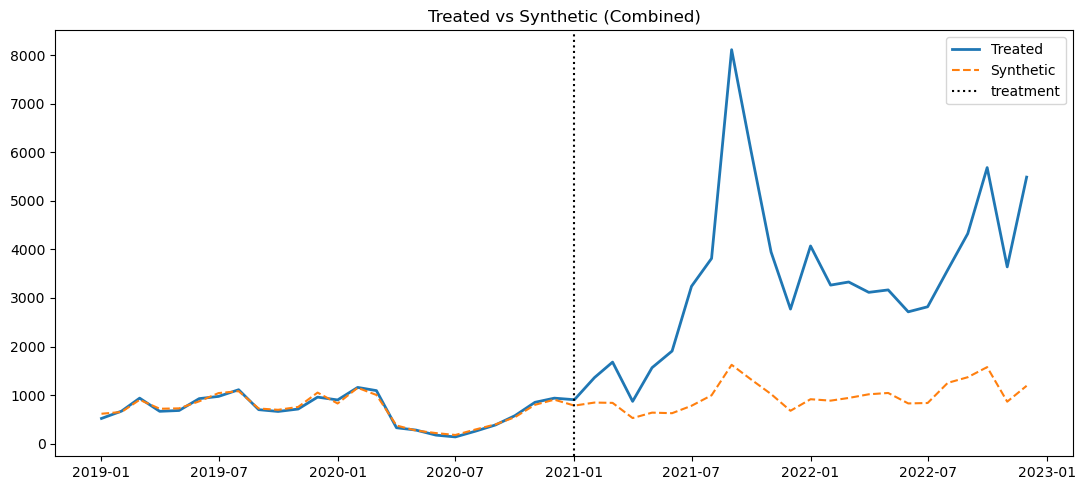

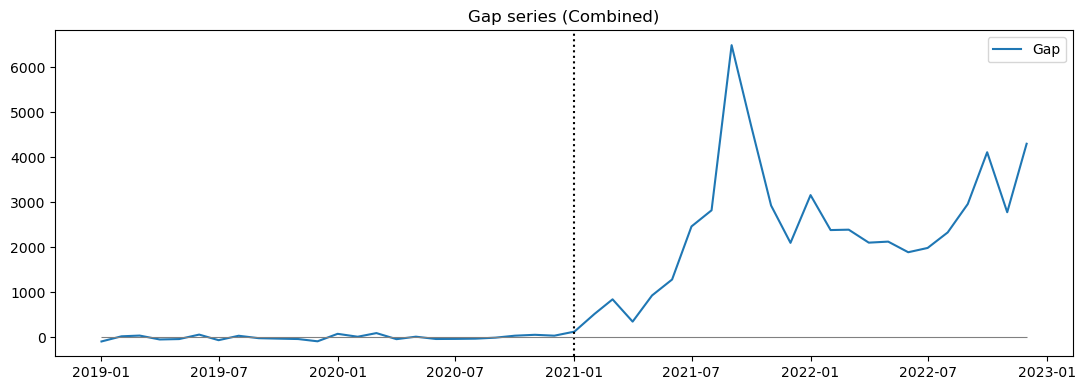

Pre-fit validity (Combined): {'pre_r2': 0.9715, 'pre_corr': 0.9871, 'pre_mape': 0.082, 'pre_gap_slope': 1.7733, 'pre_gap_trend_p': 0.2454}


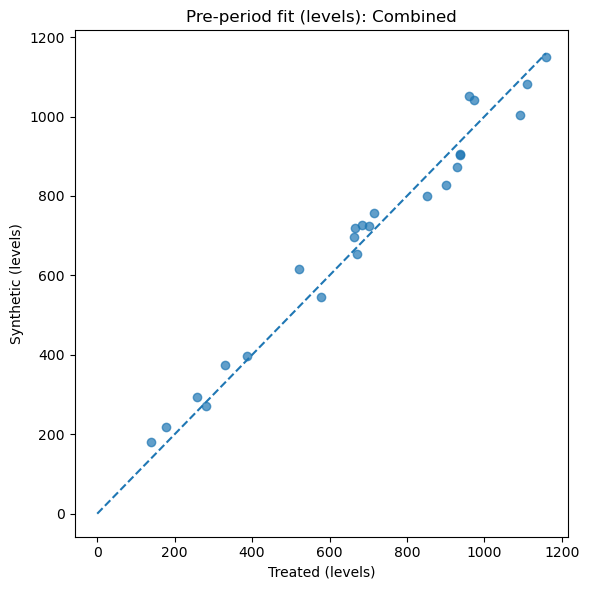

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


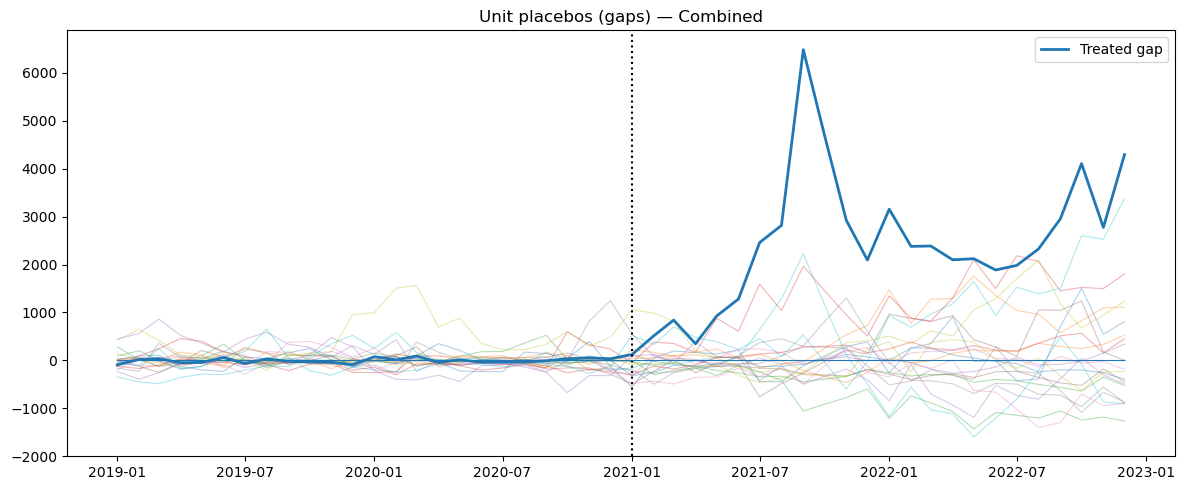

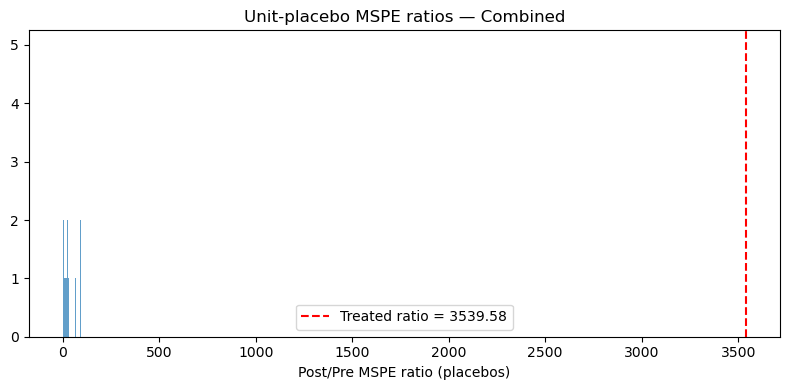

fit status: optimal
Share-of-US test: Post jump = 0.0057 (p=0.029), trend = 0.0001 (p=0.446)


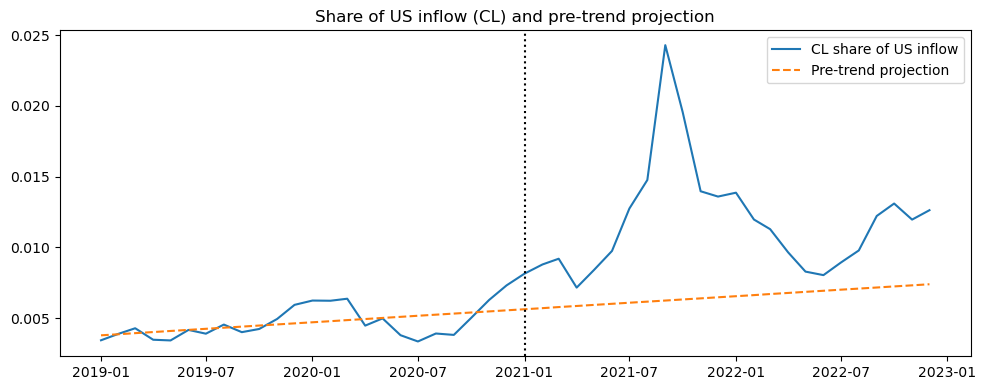

Average monthly post gap (levels): origin-only = 2788.3, destination-only = 1716.0


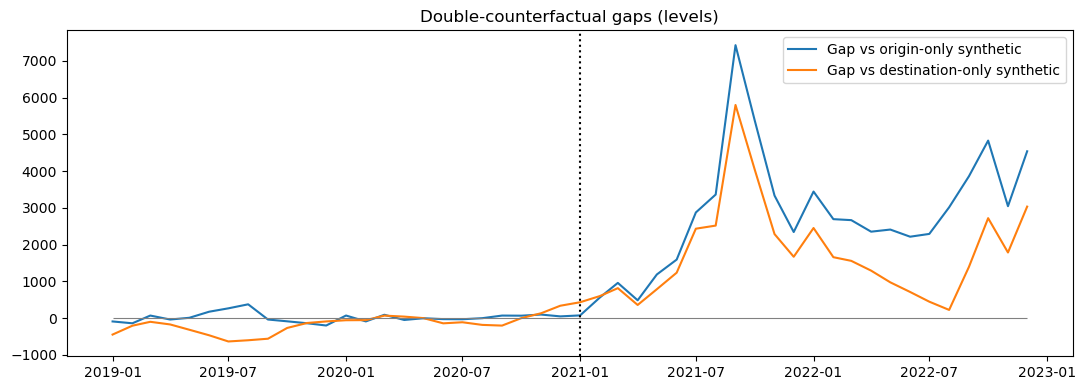

=== Synthetic Control Summary (spec) === scale=raw; group>=0.4; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors     50.475    2810.618              3100.68                0.048          20               57975.40               247.50
                    Origin-only donors    127.536    3231.367               641.96                0.091          10               66919.59               462.14
               Destination-only donors    292.942    2140.413                53.39                0.182          10               41183.53               102.40
Combined (leave top donor out: CL->CA)     51.411    2856.652              3087.44                0.050          19               59119.29               265.34


month-placebos: 100%|██████████| 12/12 [00:00<00:00, 195.33it/s]


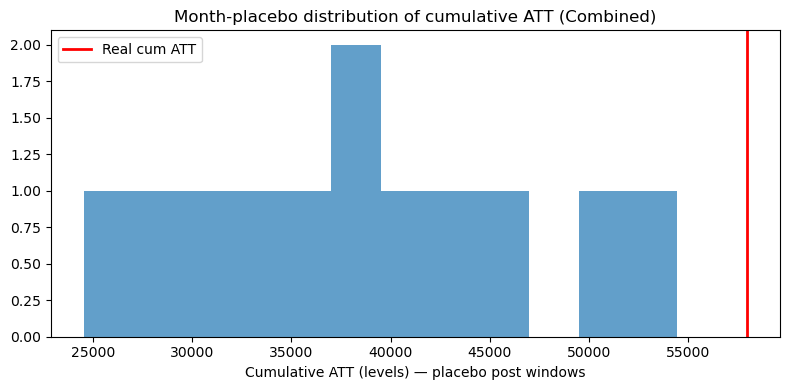

All scenarios completed. Results saved in: /Users/wenlanzhang/PycharmProjects/Mapineq/src/case_study/Migration/DID/SCM_results/CL


In [9]:
# ----------------------------- Main Result -----------------------------
if __name__ == "__main__":
    # 1) Load
    df = load_data(CSV_PATH)

    # 2) Treated monthly rows and donor selection by similarity
    treat_df = df[(df["country_to"] == TREATED_TO) & (df["country_from"] == TREATED_FROM)].copy()
    if treat_df.empty:
        raise ValueError(f"Treated flow {TREATED_FROM}->{TREATED_TO} not found in data.")

    same_origin_m, same_dest_m, treated_total = pick_similar_donors(
        df, TREATED_FROM, TREATED_TO, EXCLUDE_ORIGINS, TOP_K
    )

    # 3) Control dataframe and panel (levels)
    df_control = pd.concat([treat_df, same_origin_m, same_dest_m], ignore_index=True)
    panel = make_panel(df_control)

    treated_unit = f"{TREATED_FROM}->{TREATED_TO}"
    if treated_unit not in panel.columns:
        raise ValueError(f"Treated unit {treated_unit} not in panel columns.")

    # OPTIONAL: export full panel (levels) once for R
    panel_levels = panel.copy()
    panel_levels = pd.DataFrame({
        "date": panel_levels.index,
        **{c: panel_levels[c].values for c in panel_levels.columns}
    })
    write_csv(panel_levels, "panel_levels_full")

    # Build donor labels from the *levels* panel
    donors_dest_labels = [c for c in panel.columns if c.endswith(f"->{TREATED_TO}") and c != treated_unit]
    donors_orig_labels = [c for c in panel.columns if c.startswith(f"{TREATED_FROM}->") and c != treated_unit]
    donors_combined_labels = donors_dest_labels + donors_orig_labels

    # Scenarios to run
    log_opts = [True, False] if RUN_BOTH_LOG_SPECS else [USE_LOG]
    constraint_opts = CONSTRAINT_LEVELS if RUN_SENSITIVITY_CONSTRAINTS else [MIN_GROUP_SHARE]

    scenarios = []
    for use_log in log_opts:
        for grp in constraint_opts:
            scenarios.append((use_log, grp, None, "base"))
            if RUN_WEIGHT_CAP_VARIANT:
                scenarios.append((use_log, grp, WEIGHT_CAP, "cap"))

    ensure_dir(OUTPUT_DIR)

    first_spec_done = False

    for (use_log, grp_share, weight_cap, tag) in scenarios:
        # 4) Build Y on chosen scale
        Y = panel.copy()
        if use_log:
            Y = pd.DataFrame(np.log1p(Y.values), index=Y.index, columns=Y.columns)

        # masks
        pre_mask = np.asarray(Y.index < TREATMENT_DATE, dtype=bool)
        post_mask = np.asarray(Y.index >= TREATMENT_DATE, dtype=bool)
        T_pre = int(pre_mask.sum())
        if T_pre < MIN_PRE_MONTHS:
            print(f"Warning: only {T_pre} pre months (< {MIN_PRE_MONTHS}). Results may be unstable.")

        # donor DataFrames
        donor_df_combined = Y[donors_combined_labels]
        donor_df_origin = Y[donors_orig_labels]
        donor_df_dest = Y[donors_dest_labels]

        # group index maps for combined
        orig_idx = [donors_combined_labels.index(d) for d in donors_orig_labels if d in donors_combined_labels]
        dest_idx = [donors_combined_labels.index(d) for d in donors_dest_labels if d in donors_combined_labels]
        group_map = {"origin": orig_idx, "destination": dest_idx}

        y_t = Y[treated_unit].values
        dates = Y.index
        treat_idx = int(pre_mask.sum())

        # 5) Fit models for this spec
        results = []
        weights_store = {}

        # Combined
        if donor_df_combined.shape[1] >= 1:
            fr_c = fit_synth(y_t, donor_df_combined.values, pre_mask,
                             group_indices=group_map, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_c = diagnostics(y_t, fr_c.synth, pre_mask, post_mask, use_log)

            # === INSERT: quick self-check for this spec (Combined) ===
            print(f"[Spec] scale={'log' if use_log else 'raw'}; grp_share={grp_share}; cap={weight_cap}")
            print("  Treated post sum (levels):",
                  float(to_level_scale(y_t, use_log)[post_mask].sum()))
            print("  Synthetic post sum, Combined (levels):",
                  float(to_level_scale(fr_c.synth, use_log)[post_mask].sum()))
            print("  Cum ATT (levels), Combined:", d_c["cum_att_levels"])
            print("  % change post, Combined:", d_c["pct_change_post"])
            print("  Fit status (Combined):", fr_c.status)
            # === END INSERT ===

            
            tr_c, placebo_c, pval_c, n_c = unit_placebos(y_t, donor_df_combined, pre_mask, post_mask)
            results.append({
                "Model": "Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})",
                "Pre_RMSPE": d_c["pre_rmspe"],
                "Post_RMSPE": d_c["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_c["mspe_ratio"],
                "Permutation_p_value": pval_c,
                "N_placebos": n_c,
                "Cumulative_ATT_levels": d_c["cum_att_levels"],
                "Percent_change_post": d_c["pct_change_post"] * 100.0,
            })
            weights_store["Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})"] = pd.DataFrame({
                "donor": donors_combined_labels,
                "weight": fr_c.weights,
                "group": ["destination" if i in dest_idx else "origin" for i in range(len(donors_combined_labels))]
            }).sort_values("weight", ascending=False)

            # ── Export: Treated vs Synthetic (Combined)
            series_c = pd.DataFrame({
                "date": dates,
                "treated": to_level_scale(y_t, use_log),
                "synthetic": to_level_scale(fr_c.synth, use_log),
                "on_model_scale_treated": y_t,
                "on_model_scale_synth": fr_c.synth,
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
            })
            write_csv(series_c, "series_combined",
                      "log" if use_log else "raw", f"grp{grp_share}",
                      f"cap{weight_cap}" if weight_cap else None)

            # Plots & validity for combined
            plt.figure(figsize=(11, 5))
            plt.plot(dates, y_t, label="Treated", linewidth=2)
            plt.plot(dates, fr_c.synth, "--", label="Synthetic")
            plt.axvline(dates[treat_idx], color="k", linestyle=":", label="treatment")
            plt.title("Treated vs Synthetic (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("fit_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            # ── Export: Gap series (Combined)
            gap_c = pd.DataFrame({
                "date": dates,
                "gap_model_scale": y_t - fr_c.synth,
                "gap_levels": to_level_scale(y_t, use_log) - to_level_scale(fr_c.synth, use_log),
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
            })
            write_csv(gap_c, "gap_combined",
                      "log" if use_log else "raw", f"grp{grp_share}",
                      f"cap{weight_cap}" if weight_cap else None)

            plt.figure(figsize=(11, 4))
            plt.plot(dates, y_t - fr_c.synth, label="Gap")
            plt.axvline(dates[treat_idx], color="k", linestyle=":")
            plt.hlines(0, dates.min(), dates.max(), colors="gray", linewidth=0.8)
            plt.title("Gap series (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("gap_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            metrics = pre_fit_validity_metrics(y_t, fr_c.synth, pre_mask, use_log)
            print("Pre-fit validity (Combined):",
                  {k: (round(v, 4) if isinstance(v, float) and np.isfinite(v) else v) for k, v in metrics.items()})

            # ── Export: Pre-fit scatter points (levels)
            prefit_scatter_c = pd.DataFrame({
                "treated_levels": to_level_scale(y_t[pre_mask], use_log),
                "synthetic_levels": to_level_scale(fr_c.synth[pre_mask], use_log),
            })
            write_csv(prefit_scatter_c, "prefit_scatter_combined_points",
                      "log" if use_log else "raw", f"grp{grp_share}",
                      f"cap{weight_cap}" if weight_cap else None)

            plot_pre_fit_scatter(dates, y_t[pre_mask], fr_c.synth[pre_mask], use_log,
                                 title="Pre-period fit (levels): Combined")
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("prefit_scatter_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            placebo_gaps_c = unit_placebo_gaps(y_t, donor_df_combined, pre_mask)
            if len(placebo_gaps_c) > 0:
                # ── Export: Unit placebo gaps (long)
                placebo_long = []
                for unit, g in placebo_gaps_c.items():
                    placebo_long.append(pd.DataFrame({
                        "date": dates,
                        "unit": unit,
                        "gap_model_scale": g,
                        "is_pre": pre_mask.astype(int),
                        "is_post": post_mask.astype(int),
                    }))
                placebo_long = pd.concat(placebo_long, ignore_index=True)
                write_csv(placebo_long, "unit_placebo_gaps_long",
                          "log" if use_log else "raw", f"grp{grp_share}",
                          f"cap{weight_cap}" if weight_cap else None)

                plt.figure(figsize=(12, 5))
                for g in placebo_gaps_c.values():
                    plt.plot(dates, g, linewidth=0.8, alpha=0.35)
                plt.plot(dates, y_t - fr_c.synth, linewidth=2.0, label='Treated gap')
                plt.axvline(dates[treat_idx], color='k', linestyle=':')
                plt.hlines(0, dates.min(), dates.max(), linewidth=0.8)
                plt.legend(); plt.title("Unit placebos (gaps) — Combined")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("unit_placebo_gaps", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                # ── Export: histogram data (MSPE ratios)
                ratios_df = pd.DataFrame({
                    "unit": list(placebo_c.keys()) + ["__treated__"],
                    "post_pre_mspe_ratio": list(placebo_c.values()) + [tr_c],
                    "is_treated": [0]*len(placebo_c) + [1],
                })
                write_csv(ratios_df, "unit_placebo_mspe_ratios",
                          "log" if use_log else "raw", f"grp{grp_share}",
                          f"cap{weight_cap}" if weight_cap else None)

                vals = np.array(list(placebo_c.values()))
                if vals.size > 0 and np.isfinite(tr_c):
                    plt.figure(figsize=(8, 4))
                    plt.hist(vals, bins=30, alpha=0.7)
                    plt.axvline(tr_c, color='red', linestyle='--', label=f"Treated ratio = {tr_c:.2f}")
                    plt.xlabel("Post/Pre MSPE ratio (placebos)"); plt.legend()
                    plt.title("Unit-placebo MSPE ratios — Combined")
                    plt.tight_layout()
                    if SAVE_FIGS:
                        figpath = OUTPUT_DIR / label_slug("unit_placebo_mspe_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                        savefig(figpath.with_suffix('.png'))
                    plt.show()

        # Origin-only (no group constraints, no cap)
        if donor_df_origin.shape[1] >= 1:
            fr_o = fit_synth(y_t, donor_df_origin.values, pre_mask)
            d_o = diagnostics(y_t, fr_o.synth, pre_mask, post_mask, use_log)
            tr_o, placebo_o, pval_o, n_o = unit_placebos(y_t, donor_df_origin, pre_mask, post_mask)
            results.append({
                "Model": "Origin-only donors",
                "Pre_RMSPE": d_o["pre_rmspe"],
                "Post_RMSPE": d_o["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_o["mspe_ratio"],
                "Permutation_p_value": pval_o,
                "N_placebos": n_o,
                "Cumulative_ATT_levels": d_o["cum_att_levels"],
                "Percent_change_post": d_o["pct_change_post"] * 100.0,
            })
            weights_store["Origin-only donors"] = pd.DataFrame({
                "donor": donors_orig_labels,
                "weight": fr_o.weights,
                "group": ["origin"] * len(donors_orig_labels)
            }).sort_values("weight", ascending=False)

            # ── Export: Origin-only series
            series_o = pd.DataFrame({
                "date": dates,
                "treated_levels": to_level_scale(y_t, use_log),
                "synthetic_levels": to_level_scale(fr_o.synth, use_log),
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
            })
            write_csv(series_o, "series_origin_only",
                      "log" if use_log else "raw", f"grp{grp_share}")

        # Destination-only (no group constraints, no cap)
        if donor_df_dest.shape[1] >= 1:

            # === INSERT: drop donors with zero pre-period mass on THIS modelling scale ===
            has_pre = (donor_df_dest.loc[pre_mask].sum(axis=0) > 0).values
            if has_pre.sum() == 0:
                print("[Note] Destination-only: no donors with pre-period mass; skipping fit.")
                # Optionally: skip the whole destination-only section
                # by wrapping everything below in an else: block.
            else:
                donor_df_dest = donor_df_dest.loc[:, has_pre]
                donors_dest_labels = [d for d, keep in zip(donors_dest_labels, has_pre) if keep]
            # === END INSERT ===
            
            fr_d = fit_synth(y_t, donor_df_dest.values, pre_mask)
            d_d = diagnostics(y_t, fr_d.synth, pre_mask, post_mask, use_log)

            print("fit status:", fr_d.status)  # do this for fr_c / fr_o too if helpful

            # (optional) log if the synthetic has ~0 post mass
            synth_post_sum_d = float(to_level_scale(fr_d.synth, use_log)[post_mask].sum())
            if synth_post_sum_d <= 1e-9:
                print("[Note] Destination-only: synthetic post sum is ~0; % change suppressed. Fit status:", fr_d.status)

            
            tr_d, placebo_d, pval_d, n_d = unit_placebos(y_t, donor_df_dest, pre_mask, post_mask)
            results.append({
                "Model": "Destination-only donors",
                "Pre_RMSPE": d_d["pre_rmspe"],
                "Post_RMSPE": d_d["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_d["mspe_ratio"],
                "Permutation_p_value": pval_d,
                "N_placebos": n_d,
                "Cumulative_ATT_levels": d_d["cum_att_levels"],
                "Percent_change_post": d_d["pct_change_post"] * 100.0,
            })
            weights_store["Destination-only donors"] = pd.DataFrame({
                "donor": donors_dest_labels,
                "weight": fr_d.weights,
                "group": ["destination"] * len(donors_dest_labels)
            }).sort_values("weight", ascending=False)

            # ── Export: Destination-only series
            series_d = pd.DataFrame({
                "date": dates,
                "treated_levels": to_level_scale(y_t, use_log),
                "synthetic_levels": to_level_scale(fr_d.synth, use_log),
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
            })
            write_csv(series_d, "series_destination_only",
                      "log" if use_log else "raw", f"grp{grp_share}")

        # === Additional diagnostics for main spec only (share-of-US and double-gap) ===
        # Run only for the primary presentation spec to avoid spam: group>=0.40, no cap (both log and raw scales)
        if abs(grp_share - 0.40) < 1e-9 and (weight_cap is None):
            # --- Share-of-US inflow test: CL->US share of total US inflow
            df_with_month = df.assign(month=pd.to_datetime(df['migration_month']).dt.to_period('M').dt.to_timestamp())
            us_total = (df_with_month[df_with_month['country_to'] == TREATED_TO]
                        .groupby('month', as_index=True)['num_migrants'].sum().to_frame('us_total'))
            cl_us = (df_with_month[(df_with_month['country_to'] == TREATED_TO) & (df_with_month['country_from'] == TREATED_FROM)]
                     .groupby('month', as_index=True)['num_migrants'].sum().to_frame('cl_us'))
            share = cl_us.join(us_total, how='outer').fillna(0.0)
            share['share'] = share['cl_us'] / share['us_total'].replace({0.0: np.nan})
            # Align to modelling timeline
            share = share.reindex(dates).interpolate(limit_direction='both')

            # Regression: share ~ const + trend + Post (HAC robust SEs)
            t = np.arange(len(dates))
            post_ind = post_mask.astype(int)
            X = sm.add_constant(np.column_stack([t, post_ind]))
            mdl = sm.OLS(share['share'].values, X, missing='drop')
            res = mdl.fit(cov_type='HAC', cov_kwds={'maxlags': 6})  # monthly data
            beta_post = float(res.params[2])
            p_post = float(res.pvalues[2])
            beta_trend = float(res.params[1]); p_trend = float(res.pvalues[1])
            print(f"Share-of-US test: Post jump = {beta_post:.4f} (p={p_post:.3f}), trend = {beta_trend:.4f} (p={p_trend:.3f})")

            # Pre-trend estimated using pre only; project forward for visualization
            pre_t = t[pre_mask]
            pre_y = share['share'].values[pre_mask]
            preX = sm.add_constant(pre_t)
            pre_fit = sm.OLS(pre_y, preX).fit()
            share_proj = pre_fit.predict(sm.add_constant(t))

            # ── Export: Share-of-US series + projection
            share_out = pd.DataFrame({
                "date": dates,
                "share": share["share"].values,
                "pretrend_projection": share_proj,
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
                "beta_post": beta_post,
                "p_post": p_post,
                "beta_trend": beta_trend,
                "p_trend": p_trend,
            })
            write_csv(share_out, "share_of_dest_series_and_projection",
                      "log" if use_log else "raw", f"grp{grp_share}")

            plt.figure(figsize=(10, 4))
            plt.plot(dates, share['share'].values, label=f'{TREATED_FROM} share of {TREATED_TO} inflow')
            plt.plot(dates, share_proj, '--', label='Pre-trend projection')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.legend(); plt.title(f'Share of {TREATED_TO} inflow ({TREATED_FROM}) and pre-trend projection')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'share_us_pretrend.png')
            plt.show()

            # --- Double-counterfactual decomposition: gaps vs origin-only and destination-only synthetics (levels)
            yL = to_level_scale(y_t, use_log)
            sO = to_level_scale(fr_o.synth, use_log) if donor_df_origin.shape[1] >= 1 else np.full_like(yL, np.nan)
            sD = to_level_scale(fr_d.synth, use_log) if donor_df_dest.shape[1] >= 1 else np.full_like(yL, np.nan)
            gap_O = yL - sO
            gap_D = yL - sD
            avg_gap_O = float(np.nanmean(gap_O[post_mask])) if donor_df_origin.shape[1] >= 1 else np.nan
            avg_gap_D = float(np.nanmean(gap_D[post_mask])) if donor_df_dest.shape[1] >= 1 else np.nan
            print(f"Average monthly post gap (levels): origin-only = {avg_gap_O:.1f}, destination-only = {avg_gap_D:.1f}")

            # ── Export: Double-counterfactual gaps (levels)
            double_gap = pd.DataFrame({
                "date": dates,
                "treated_levels": yL,
                "synthetic_origin_levels": sO,
                "synthetic_destination_levels": sD,
                "gap_vs_origin_levels": gap_O,
                "gap_vs_destination_levels": gap_D,
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
            })
            write_csv(double_gap, "double_counterfactual_gaps_levels",
                      "log" if use_log else "raw", f"grp{grp_share}")

            plt.figure(figsize=(11, 4))
            if donor_df_origin.shape[1] >= 1:
                plt.plot(dates, gap_O, label='Gap vs origin-only synthetic')
            if donor_df_dest.shape[1] >= 1:
                plt.plot(dates, gap_D, label='Gap vs destination-only synthetic')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.hlines(0, dates.min(), dates.max(), colors='gray', linewidth=0.8)
            plt.legend(); plt.title('Double-counterfactual gaps (levels)')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'double_gap_levels.png')
            plt.show()

        # Combined (leave top donor out)
        if donor_df_combined.shape[1] >= 2:
            top_idx = int(np.argmax(fr_c.weights))
            top_donor = donors_combined_labels[top_idx]
            donors_minus = [d for d in donors_combined_labels if d != top_donor]
            donor_df_minus = Y[donors_minus]

            orig_idx_m = [donors_minus.index(d) for d in donors_orig_labels if d in donors_minus]
            dest_idx_m = [donors_minus.index(d) for d in donors_dest_labels if d in donors_minus]
            group_map_m = {"origin": orig_idx_m, "destination": dest_idx_m}

            fr_m = fit_synth(y_t, donor_df_minus.values, pre_mask,
                             group_indices=group_map_m, min_group_share=grp_share,
                             weight_cap=weight_cap)
            
            d_m = diagnostics(y_t, fr_m.synth, pre_mask, post_mask, use_log)
            tr_m, placebo_m, pval_m, n_m = unit_placebos(y_t, donor_df_minus, pre_mask, post_mask)
            model_name_m = f"Combined (leave top donor out: {top_donor})" if weight_cap is None else f"Combined (leave top donor out: {top_donor}, cap {weight_cap:.2f})"
            results.append({
                "Model": model_name_m,
                "Pre_RMSPE": d_m["pre_rmspe"],
                "Post_RMSPE": d_m["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_m["mspe_ratio"],
                "Permutation_p_value": pval_m,
                "N_placebos": n_m,
                "Cumulative_ATT_levels": d_m["cum_att_levels"],
                "Percent_change_post": d_m["pct_change_post"] * 100.0,
            })
            weights_store[model_name_m] = pd.DataFrame({
                "donor": donors_minus,
                "weight": fr_m.weights,
                "group": ["destination" if i in dest_idx_m else "origin" for i in range(len(donors_minus))]
            }).sort_values("weight", ascending=False)

            # ── Export: Combined minus top donor series
            series_m = pd.DataFrame({
                "date": dates,
                "treated_levels": to_level_scale(y_t, use_log),
                "synthetic_levels": to_level_scale(fr_m.synth, use_log),
                "is_pre": pre_mask.astype(int),
                "is_post": post_mask.astype(int),
                "left_out_donor": top_donor,
            })
            write_csv(series_m, "series_combined_minus_top",
                      "log" if use_log else "raw", f"grp{grp_share}",
                      f"cap{weight_cap}" if weight_cap else None)

        # 6) Summary & export
        summary_df = pd.DataFrame(results)
        if not summary_df.empty:
            summary_df = summary_df[[
                "Model", "Pre_RMSPE", "Post_RMSPE", "Post/Pre_MSPE_Ratio",
                "Permutation_p_value", "N_placebos",
                "Cumulative_ATT_levels", "Percent_change_post"
            ]]
            summary_df = summary_df.round({
                "Pre_RMSPE": 3, "Post_RMSPE": 3, "Post/Pre_MSPE_Ratio": 2,
                "Permutation_p_value": 3, "Cumulative_ATT_levels": 2, "Percent_change_post": 2
            })
            print(f"=== Synthetic Control Summary (spec) === scale={'log' if use_log else 'raw'}; group>={grp_share}; cap={weight_cap}")
            print(summary_df.to_string(index=False))

            if SAVE_TABLES:
                label = label_slug("summary", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                summary_path = OUTPUT_DIR / f"{label}.csv"
                summary_df.to_csv(summary_path, index=False)

                # Export weights per model (you already had this)
                for name, wdf in weights_store.items():
                    wlabel = label_slug("weights", name, "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    wdf.to_csv(OUTPUT_DIR / f"{wlabel}.csv", index=False)

        # 7) Optional month-placebos (run only for the first spec unless configured)
        run_pl = RUN_MONTH_PLACEBOS and (PLACEBOS_FOR_ALL_SPECS or not first_spec_done)
        if run_pl and donor_df_combined.shape[1] >= 1:
            month_pl = month_placebos(y_t, donor_df_combined, Y.index, TREATMENT_DATE, use_log, N_PLACEBO_MONTHS)

            # Ensure month-placebos table is written (guarded by SAVE_TABLES)
            if SAVE_TABLES and month_pl is not None and not month_pl.empty:
                label = label_slug("month_placebos", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                month_pl.to_csv(OUTPUT_DIR / f"{label}.csv", index=False)

            if month_pl is not None and not month_pl.empty:
                real_cum_att = summary_df.loc[summary_df["Model"].str.startswith("Combined donors"), "Cumulative_ATT_levels"]
                real_val = float(real_cum_att.iloc[0]) if len(real_cum_att) > 0 else np.nan
                valid = month_pl[month_pl["cum_att_levels"].notna()]

                plt.figure(figsize=(8, 4))
                plt.hist(valid["cum_att_levels"], bins=12, alpha=0.7)
                if np.isfinite(real_val):
                    plt.axvline(real_val, color="red", linewidth=2, label="Real cum ATT")
                    plt.legend()
                plt.xlabel("Cumulative ATT (levels) — placebo post windows")
                plt.title("Month-placebo distribution of cumulative ATT (Combined)")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("month_placebos_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

            first_spec_done = True

    print(f"All scenarios completed. Results saved in: {OUTPUT_DIR.resolve()}")

In [ ]:
# ----------------------------- All Result -----------------------------

if __name__ == "__main__":
    # 1) Load
    df = load_data(CSV_PATH)

    # 2) Treated monthly rows and donor selection by similarity
    treat_df = df[(df["country_to"] == TREATED_TO) & (df["country_from"] == TREATED_FROM)].copy()
    if treat_df.empty:
        raise ValueError(f"Treated flow {TREATED_FROM}->{TREATED_TO} not found in data.")

    same_origin_m, same_dest_m, treated_total = pick_similar_donors(
        df, TREATED_FROM, TREATED_TO, EXCLUDE_ORIGINS, TOP_K
    )

    # 3) Control dataframe and panel (levels)
    df_control = pd.concat([treat_df, same_origin_m, same_dest_m], ignore_index=True)
    panel = make_panel(df_control)

    treated_unit = f"{TREATED_FROM}->{TREATED_TO}"
    if treated_unit not in panel.columns:
        raise ValueError(f"Treated unit {treated_unit} not in panel columns.")

    # Build donor labels from the *levels* panel
    donors_dest_labels = [c for c in panel.columns if c.endswith(f"->{TREATED_TO}") and c != treated_unit]
    donors_orig_labels = [c for c in panel.columns if c.startswith(f"{TREATED_FROM}->") and c != treated_unit]
    donors_combined_labels = donors_dest_labels + donors_orig_labels

    # Scenarios to run
    log_opts = [True, False] if RUN_BOTH_LOG_SPECS else [USE_LOG]
    constraint_opts = CONSTRAINT_LEVELS if RUN_SENSITIVITY_CONSTRAINTS else [MIN_GROUP_SHARE]

    scenarios = []
    for use_log in log_opts:
        for grp in constraint_opts:
            scenarios.append((use_log, grp, None, "base"))
            if RUN_WEIGHT_CAP_VARIANT:
                scenarios.append((use_log, grp, WEIGHT_CAP, "cap"))

    ensure_dir(OUTPUT_DIR)

    first_spec_done = False

    for (use_log, grp_share, weight_cap, tag) in scenarios:
        # 4) Build Y on chosen scale
        Y = panel.copy()
        if use_log:
            Y = pd.DataFrame(np.log1p(Y.values), index=Y.index, columns=Y.columns)

        # masks
        pre_mask = np.asarray(Y.index < TREATMENT_DATE, dtype=bool)
        post_mask = np.asarray(Y.index >= TREATMENT_DATE, dtype=bool)
        T_pre = int(pre_mask.sum())
        if T_pre < MIN_PRE_MONTHS:
            print(f"Warning: only {T_pre} pre months (< {MIN_PRE_MONTHS}). Results may be unstable.")

        # donor DataFrames
        donor_df_combined = Y[donors_combined_labels]
        donor_df_origin = Y[donors_orig_labels]
        donor_df_dest = Y[donors_dest_labels]

        # group index maps for combined
        orig_idx = [donors_combined_labels.index(d) for d in donors_orig_labels if d in donors_combined_labels]
        dest_idx = [donors_combined_labels.index(d) for d in donors_dest_labels if d in donors_combined_labels]
        group_map = {"origin": orig_idx, "destination": dest_idx}

        y_t = Y[treated_unit].values
        dates = Y.index
        treat_idx = int(pre_mask.sum())

        # 5) Fit models for this spec
        results = []
        weights_store = {}

        # Combined
        if donor_df_combined.shape[1] >= 1:
            fr_c = fit_synth(y_t, donor_df_combined.values, pre_mask,
                             group_indices=group_map, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_c = diagnostics(y_t, fr_c.synth, pre_mask, post_mask, use_log)
            tr_c, placebo_c, pval_c, n_c = unit_placebos(y_t, donor_df_combined, pre_mask, post_mask)
            results.append({
                "Model": "Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})",
                "Pre_RMSPE": d_c["pre_rmspe"],
                "Post_RMSPE": d_c["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_c["mspe_ratio"],
                "Permutation_p_value": pval_c,
                "N_placebos": n_c,
                "Cumulative_ATT_levels": d_c["cum_att_levels"],
                "Percent_change_post": d_c["pct_change_post"] * 100.0,
            })
            weights_store["Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})"] = pd.DataFrame({
                "donor": donors_combined_labels,
                "weight": fr_c.weights,
                "group": ["destination" if i in dest_idx else "origin" for i in range(len(donors_combined_labels))]
            }).sort_values("weight", ascending=False)

            # Plots & validity for combined
            plt.figure(figsize=(11, 5))
            plt.plot(dates, y_t, label="Treated", linewidth=2)
            plt.plot(dates, fr_c.synth, "--", label="Synthetic")
            plt.axvline(dates[treat_idx], color="k", linestyle=":", label="treatment")
            plt.title("Treated vs Synthetic (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("fit_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            plt.figure(figsize=(11, 4))
            plt.plot(dates, y_t - fr_c.synth, label="Gap")
            plt.axvline(dates[treat_idx], color="k", linestyle=":")
            plt.hlines(0, dates.min(), dates.max(), colors="gray", linewidth=0.8)
            plt.title("Gap series (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("gap_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            metrics = pre_fit_validity_metrics(y_t, fr_c.synth, pre_mask, use_log)
            print("Pre-fit validity (Combined):",
                  {k: (round(v, 4) if isinstance(v, float) and np.isfinite(v) else v) for k, v in metrics.items()})
            plot_pre_fit_scatter(dates, y_t[pre_mask], fr_c.synth[pre_mask], use_log,
                                 title="Pre-period fit (levels): Combined")
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("prefit_scatter_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))

            placebo_gaps_c = unit_placebo_gaps(y_t, donor_df_combined, pre_mask)
            if len(placebo_gaps_c) > 0:
                plt.figure(figsize=(12, 5))
                for g in placebo_gaps_c.values():
                    plt.plot(dates, g, linewidth=0.8, alpha=0.35)
                plt.plot(dates, y_t - fr_c.synth, linewidth=2.0, label='Treated gap')
                plt.axvline(dates[treat_idx], color='k', linestyle=':')
                plt.hlines(0, dates.min(), dates.max(), linewidth=0.8)
                plt.legend(); plt.title("Unit placebos (gaps) — Combined")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("unit_placebo_gaps", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                vals = np.array(list(placebo_c.values()))
                if vals.size > 0 and np.isfinite(tr_c):
                    plt.figure(figsize=(8, 4))
                    plt.hist(vals, bins=30, alpha=0.7)
                    plt.axvline(tr_c, color='red', linestyle='--', label=f"Treated ratio = {tr_c:.2f}")
                    plt.xlabel("Post/Pre MSPE ratio (placebos)"); plt.legend()
                    plt.title("Unit-placebo MSPE ratios — Combined")
                    plt.tight_layout()
                    if SAVE_FIGS:
                        figpath = OUTPUT_DIR / label_slug("unit_placebo_mspe_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                        savefig(figpath.with_suffix('.png'))
                    plt.show()

        # Origin-only (no group constraints, no cap)
        if donor_df_origin.shape[1] >= 1:
            fr_o = fit_synth(y_t, donor_df_origin.values, pre_mask)
            d_o = diagnostics(y_t, fr_o.synth, pre_mask, post_mask, use_log)
            tr_o, placebo_o, pval_o, n_o = unit_placebos(y_t, donor_df_origin, pre_mask, post_mask)
            results.append({
                "Model": "Origin-only donors",
                "Pre_RMSPE": d_o["pre_rmspe"],
                "Post_RMSPE": d_o["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_o["mspe_ratio"],
                "Permutation_p_value": pval_o,
                "N_placebos": n_o,
                "Cumulative_ATT_levels": d_o["cum_att_levels"],
                "Percent_change_post": d_o["pct_change_post"] * 100.0,
            })
            weights_store["Origin-only donors"] = pd.DataFrame({
                "donor": donors_orig_labels,
                "weight": fr_o.weights,
                "group": ["origin"] * len(donors_orig_labels)
            }).sort_values("weight", ascending=False)

        # Destination-only (no group constraints, no cap)
        if donor_df_dest.shape[1] >= 1:
            fr_d = fit_synth(y_t, donor_df_dest.values, pre_mask)
            d_d = diagnostics(y_t, fr_d.synth, pre_mask, post_mask, use_log)
            tr_d, placebo_d, pval_d, n_d = unit_placebos(y_t, donor_df_dest, pre_mask, post_mask)
            results.append({
                "Model": "Destination-only donors",
                "Pre_RMSPE": d_d["pre_rmspe"],
                "Post_RMSPE": d_d["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_d["mspe_ratio"],
                "Permutation_p_value": pval_d,
                "N_placebos": n_d,
                "Cumulative_ATT_levels": d_d["cum_att_levels"],
                "Percent_change_post": d_d["pct_change_post"] * 100.0,
            })
            weights_store["Destination-only donors"] = pd.DataFrame({
                "donor": donors_dest_labels,
                "weight": fr_d.weights,
                "group": ["destination"] * len(donors_dest_labels)
            }).sort_values("weight", ascending=False)
        # === Additional diagnostics for main spec only (share-of-US and double-gap) ===
        # Run only for the primary presentation spec to avoid spam: group>=0.40, no cap (both log and raw scales)
        if abs(grp_share - 0.40) < 1e-9 and (weight_cap is None):
            # --- Share-of-US inflow test: CL->US share of total US inflow
            df_with_month = df.assign(month=pd.to_datetime(df['migration_month']).dt.to_period('M').dt.to_timestamp())
            us_total = (df_with_month[df_with_month['country_to'] == TREATED_TO]
                        .groupby('month', as_index=True)['num_migrants'].sum().to_frame('us_total'))
            cl_us = (df_with_month[(df_with_month['country_to'] == TREATED_TO) & (df_with_month['country_from'] == TREATED_FROM)]
                     .groupby('month', as_index=True)['num_migrants'].sum().to_frame('cl_us'))
            share = cl_us.join(us_total, how='outer').fillna(0.0)
            share['share'] = share['cl_us'] / share['us_total'].replace({0.0: np.nan})
            # Align to modelling timeline
            share = share.reindex(dates).interpolate(limit_direction='both')

            # Regression: share ~ const + trend + Post (HAC robust SEs)
            t = np.arange(len(dates))
            post_ind = post_mask.astype(int)
            X = sm.add_constant(np.column_stack([t, post_ind]))
            mdl = sm.OLS(share['share'].values, X, missing='drop')
            res = mdl.fit(cov_type='HAC', cov_kwds={'maxlags': 6})  # monthly data
            beta_post = float(res.params[2])
            p_post = float(res.pvalues[2])
            beta_trend = float(res.params[1]); p_trend = float(res.pvalues[1])
            print(f"Share-of-US test: Post jump = {beta_post:.4f} (p={p_post:.3f}), trend = {beta_trend:.4f} (p={p_trend:.3f})")

            # Pre-trend estimated using pre only; project forward for visualization
            pre_t = t[pre_mask]
            pre_y = share['share'].values[pre_mask]
            preX = sm.add_constant(pre_t)
            pre_fit = sm.OLS(pre_y, preX).fit()
            share_proj = pre_fit.predict(sm.add_constant(t))

            plt.figure(figsize=(10, 4))
            plt.plot(dates, share['share'].values, label=f'{TREATED_FROM} share of {TREATED_TO} inflow')
            plt.plot(dates, share_proj, '--', label='Pre-trend projection')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.legend(); plt.title(f'Share of {TREATED_TO} inflow ({TREATED_FROM}) and pre-trend projection')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'share_us_pretrend.png')
            plt.show()

            # --- Double-counterfactual decomposition: gaps vs origin-only and destination-only synthetics (levels)
            yL = to_level_scale(y_t, use_log)
            sO = to_level_scale(fr_o.synth, use_log) if donor_df_origin.shape[1] >= 1 else np.full_like(yL, np.nan)
            sD = to_level_scale(fr_d.synth, use_log) if donor_df_dest.shape[1] >= 1 else np.full_like(yL, np.nan)
            gap_O = yL - sO
            gap_D = yL - sD
            avg_gap_O = float(np.nanmean(gap_O[post_mask])) if donor_df_origin.shape[1] >= 1 else np.nan
            avg_gap_D = float(np.nanmean(gap_D[post_mask])) if donor_df_dest.shape[1] >= 1 else np.nan
            print(f"Average monthly post gap (levels): origin-only = {avg_gap_O:.1f}, destination-only = {avg_gap_D:.1f}")

            plt.figure(figsize=(11, 4))
            if donor_df_origin.shape[1] >= 1:
                plt.plot(dates, gap_O, label='Gap vs origin-only synthetic')
            if donor_df_dest.shape[1] >= 1:
                plt.plot(dates, gap_D, label='Gap vs destination-only synthetic')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.hlines(0, dates.min(), dates.max(), colors='gray', linewidth=0.8)
            plt.legend(); plt.title('Double-counterfactual gaps (levels)')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'double_gap_levels.png')
            plt.show()

        # Combined (leave top donor out)
        if donor_df_combined.shape[1] >= 2:
            top_idx = int(np.argmax(fr_c.weights))
            top_donor = donors_combined_labels[top_idx]
            donors_minus = [d for d in donors_combined_labels if d != top_donor]
            donor_df_minus = Y[donors_minus]

            orig_idx_m = [donors_minus.index(d) for d in donors_orig_labels if d in donors_minus]
            dest_idx_m = [donors_minus.index(d) for d in donors_dest_labels if d in donors_minus]
            group_map_m = {"origin": orig_idx_m, "destination": dest_idx_m}

            fr_m = fit_synth(y_t, donor_df_minus.values, pre_mask,
                             group_indices=group_map_m, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_m = diagnostics(y_t, fr_m.synth, pre_mask, post_mask, use_log)
            tr_m, placebo_m, pval_m, n_m = unit_placebos(y_t, donor_df_minus, pre_mask, post_mask)
            model_name_m = f"Combined (leave top donor out: {top_donor})" if weight_cap is None else f"Combined (leave top donor out: {top_donor}, cap {weight_cap:.2f})"
            results.append({
                "Model": model_name_m,
                "Pre_RMSPE": d_m["pre_rmspe"],
                "Post_RMSPE": d_m["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_m["mspe_ratio"],
                "Permutation_p_value": pval_m,
                "N_placebos": n_m,
                "Cumulative_ATT_levels": d_m["cum_att_levels"],
                "Percent_change_post": d_m["pct_change_post"] * 100.0,
            })
            weights_store[model_name_m] = pd.DataFrame({
                "donor": donors_minus,
                "weight": fr_m.weights,
                "group": ["destination" if i in dest_idx_m else "origin" for i in range(len(donors_minus))]
            }).sort_values("weight", ascending=False)

        # 6) Summary & export
        summary_df = pd.DataFrame(results)
        if not summary_df.empty:
            summary_df = summary_df[[
                "Model", "Pre_RMSPE", "Post_RMSPE", "Post/Pre_MSPE_Ratio",
                "Permutation_p_value", "N_placebos",
                "Cumulative_ATT_levels", "Percent_change_post"
            ]]
            summary_df = summary_df.round({
                "Pre_RMSPE": 3, "Post_RMSPE": 3, "Post/Pre_MSPE_Ratio": 2,
                "Permutation_p_value": 3, "Cumulative_ATT_levels": 2, "Percent_change_post": 2
            })
            print(f"=== Synthetic Control Summary (spec) === scale={'log' if use_log else 'raw'}; group>={grp_share}; cap={weight_cap}")
            print(summary_df.to_string(index=False))

            if SAVE_TABLES:
                label = label_slug("summary", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                summary_path = OUTPUT_DIR / f"{label}.csv"
                summary_df.to_csv(summary_path, index=False)

                # Export weights per model
                for name, wdf in weights_store.items():
                    wlabel = label_slug("weights", name, "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    wdf.to_csv(OUTPUT_DIR / f"{wlabel}.csv", index=False)

        # 7) Optional month-placebos (run only for the first spec unless configured)
        run_pl = RUN_MONTH_PLACEBOS and (PLACEBOS_FOR_ALL_SPECS or not first_spec_done)
        if run_pl and donor_df_combined.shape[1] >= 1:
            month_pl = month_placebos(y_t, donor_df_combined, Y.index, TREATMENT_DATE, use_log, N_PLACEBO_MONTHS)
            if not month_pl.empty:
                real_cum_att = summary_df.loc[summary_df["Model"].str.startswith("Combined donors"), "Cumulative_ATT_levels"]
                real_val = float(real_cum_att.iloc[0]) if len(real_cum_att) > 0 else np.nan
                valid = month_pl[month_pl["cum_att_levels"].notna()]

                plt.figure(figsize=(8, 4))
                plt.hist(valid["cum_att_levels"], bins=12, alpha=0.7)
                if np.isfinite(real_val):
                    plt.axvline(real_val, color="red", linewidth=2, label="Real cum ATT")
                    plt.legend()
                plt.xlabel("Cumulative ATT (levels) — placebo post windows")
                plt.title("Month-placebo distribution of cumulative ATT (Combined)")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("month_placebos_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                if SAVE_TABLES:
                    label = label_slug("month_placebos", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    month_pl.to_csv(OUTPUT_DIR / f"{label}.csv", index=False)

            first_spec_done = True

    print(f"All scenarios completed. Results saved in: {OUTPUT_DIR.resolve()}")

In [ ]:
df = pd.DataFrame(weights_store['Combined donors'])

# Separate origin and destination
origin_df = df[df['group'] == 'origin'][['donor','weight']].reset_index(drop=True)
destination_df = df[df['group'] == 'destination'][['donor','weight']].reset_index(drop=True)

# Make the combined table
combined = pd.concat([destination_df, origin_df], axis=1)
combined.columns = ['Destination Donor','Destination Weight','Origin Donor','Origin Weight']

# Optional: round weights for readability
combined['Destination Weight'] = combined['Destination Weight'].round(4)
combined['Origin Weight'] = combined['Origin Weight'].round(4)

combined